In [3]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add parent directory to sys.path
sys.path.append(parent_dir)

print(parent_dir)


/home/adam/Documents/dev/gradual-aacbr/examples



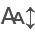

In [4]:
import torch
import torch.optim as optim
from itables import init_notebook_mode, show
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import importlib
from ray import tune

import deeparguing.gradual_aacbr as gradual_aacbr
import deeparguing.semantics.relu_semantics as rs
import deeparguing.base_scores.feature_weighted_base_score as fwbs
import deeparguing.casebase_edge_weights.SM_partial_order as smpo
import deeparguing.irrelevance_edge_weights.regular_irrelevance as ri

from deeparguing.train import static_train_model, evaluate_model
from deeparguing.tune import tune_model, objective

from helper import load_iris, split_data, cluster_data



init_notebook_mode(all_interactive=True)

In [5]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(rs)
    importlib.reload(fwbs)
    importlib.reload(smpo)
    importlib.reload(ri)

reload_imports()

In [6]:
SEED = 42

## Data Set

In [7]:
X, y = load_iris()
show(X)
show(y)

In [8]:
all_y = np.unique(y, axis=0)
show(all_y)

## Train Model

### Split into Training, Validation and Test

In [9]:
train_full, train, val, test = split_data(X, y, SEED)

print(f"Test Size:  {len(test['X'])}")
print(f"Train Size:  {len(train['X'])}")
print(f"Validation Size:  {len(val['X'])}")

Test Size:  30
Train Size:  95
Validation Size:  24


### Cluster dataset

In [10]:
GROUP_PROPORTION = 0.25 
X_centroids, y_centroids = cluster_data(train["X"], train["y"], lambda group_size: int(group_size * GROUP_PROPORTION))

8 clusters for [0. 0. 1.]
7 clusters for [0. 1. 0.]
8 clusters for [1. 0. 0.]


In [11]:
show(X_centroids)

In [12]:
X_centroids = torch.tensor(X_centroids, dtype=torch.float32)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32)

### Convert to Torch

In [13]:
X_train_full, y_train_full = torch.tensor(train_full["X"]), torch.tensor(train_full["y"], dtype=torch.float32)
X_train, y_train = torch.tensor(train["X"]), torch.tensor(train["y"], dtype=torch.float32)
X_val, y_val = torch.tensor(val["X"]), torch.tensor(val["y"], dtype=torch.float32)
X_test, y_test = torch.tensor(test["X"]), torch.tensor(test["y"], dtype=torch.float32)

### Normalize dataset

In [14]:
train_mean = X_train.mean(dim=0)
train_std = X_train.std(dim=0)

X_train = (X_train - train_mean)/train_std
X_centroids = (X_centroids - train_mean)/train_std
X_val = (X_val - train_mean)/train_std
X_test = (X_test - train_mean)/train_std



In [15]:
show(X_train.cpu().numpy())

### Train Model

In [16]:
DEFAULT_CASE = X_train.mean(axis=0)

X_DEFAULTS = DEFAULT_CASE.tile(len(all_y), 1)
Y_DEFAULTS = torch.tensor(all_y)


In [17]:
MAX_ITERS = 20
EPOCHS = 3000
USE_SYMMETRIC_ATTACKS = False
LR = 0.027724410326258685
MOMENTUM = 0.9
SHARPNESS = 0.6052368105626966
# USE_BLOCKERS = True
USE_BLOCKERS = False
# want it to work regardless of this?
TORCH_SEED = 36





In [18]:
reload_imports()
# torch.manual_seed(TORCH_SEED) # TRY DIFFERENT INITIAL WEIGHTS 

no_features = X_train.shape[-1]
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
partial_order = smpo.SMPartialOrder(no_features, sharpness=SHARPNESS)
irrelevance = ri.RegularIrrelevance(partial_order)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

Accuracy, Precision, Recall, F1
(0.2916666666666667, np.float64(0.09722222222222222), np.float64(0.3333333333333333), np.float64(0.15053763440860216))


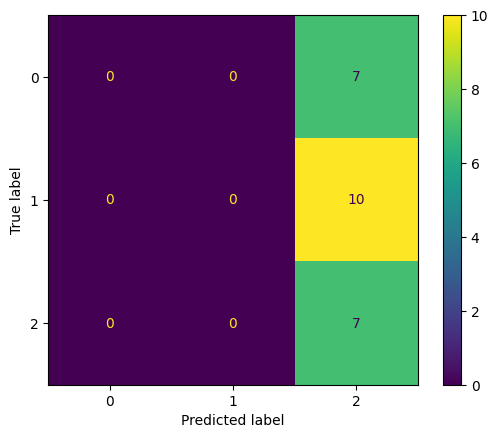

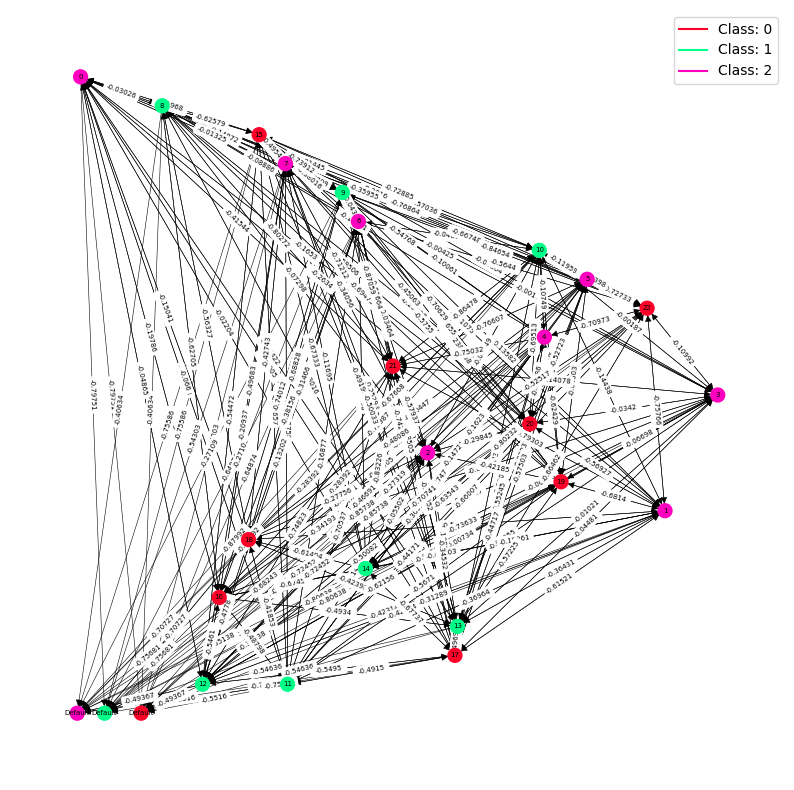

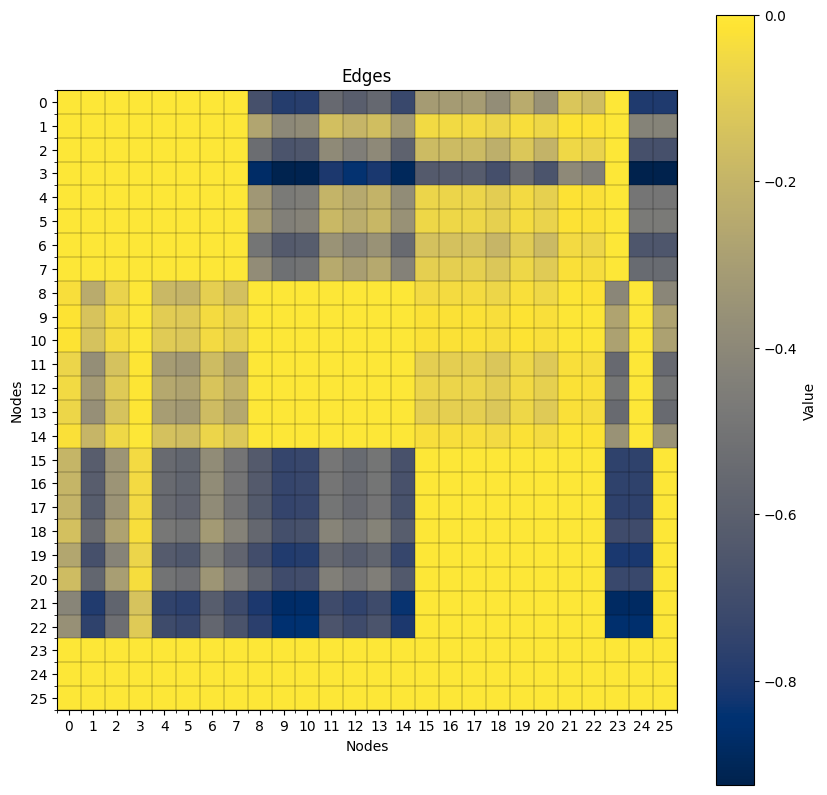

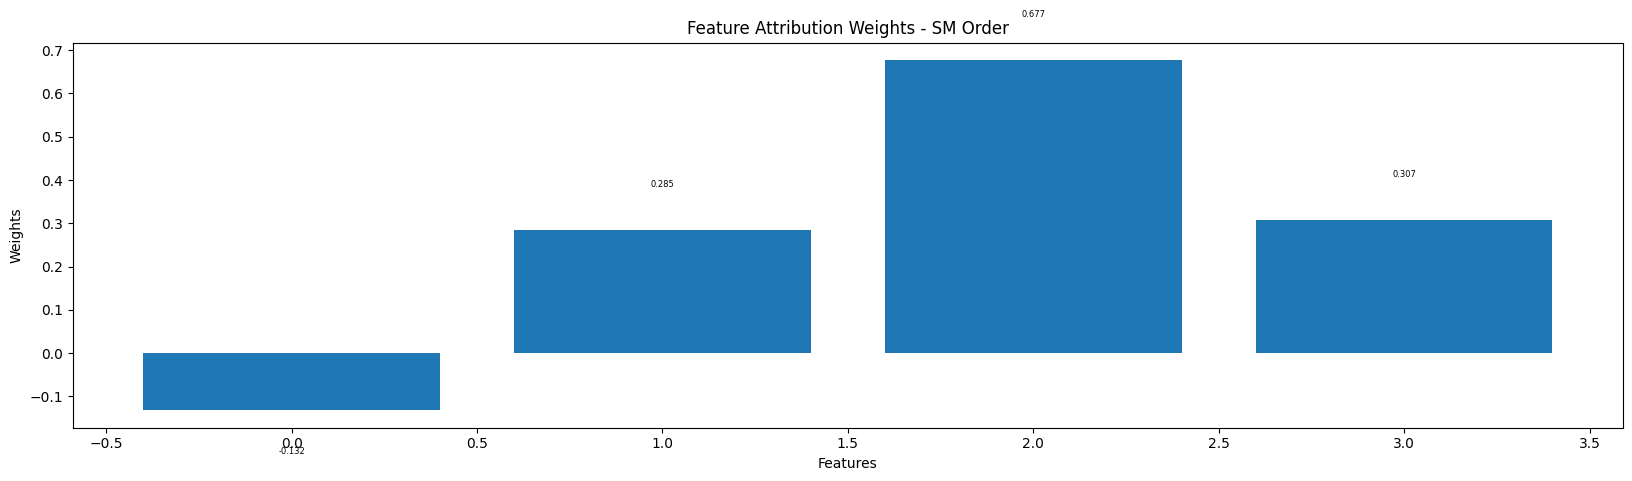

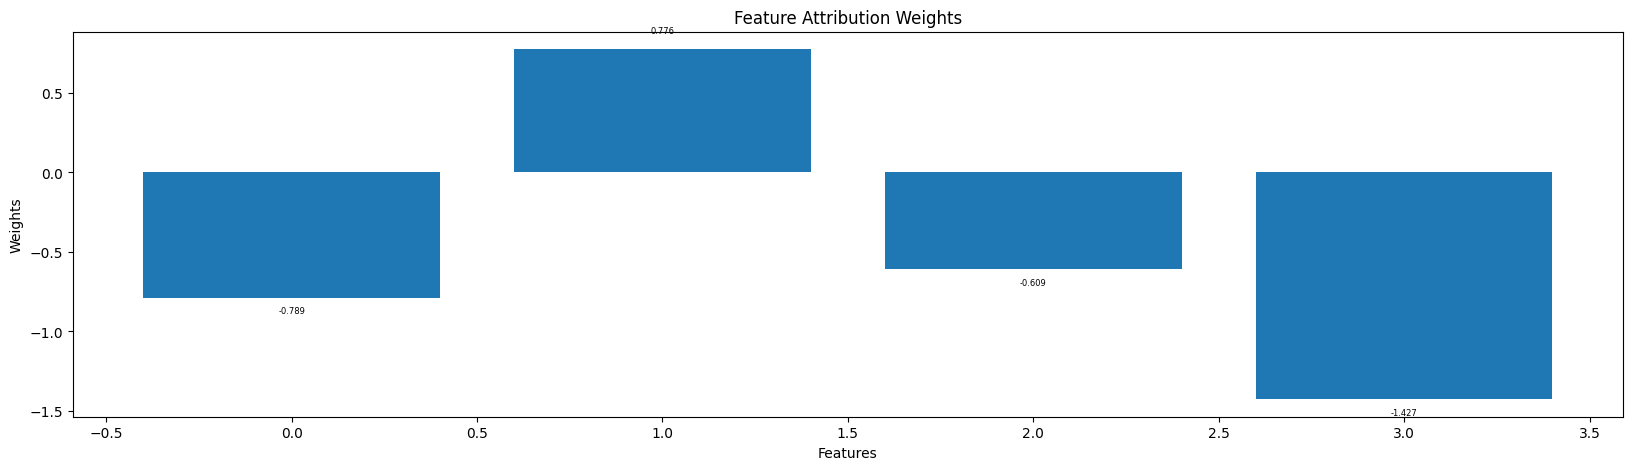

In [19]:
reload_imports()
evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=True, print_graph = True )
model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

Epoch 3000, Loss: 0.0111: 100%|██████████| 3000/3000 [00:16<00:00, 186.27it/s]


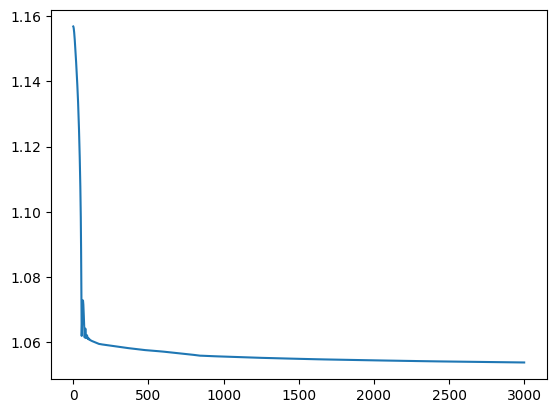

In [20]:
static_train_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, optimizer, criterion, EPOCHS, X_new_cases=X_train, y_new_cases=y_train, use_symmetric_attacks=False, use_blockers=USE_BLOCKERS, plot_loss_curve=True)

Accuracy, Precision, Recall, F1
(0.5, np.float64(0.456140350877193), np.float64(0.5714285714285715), np.float64(0.45726495726495725))


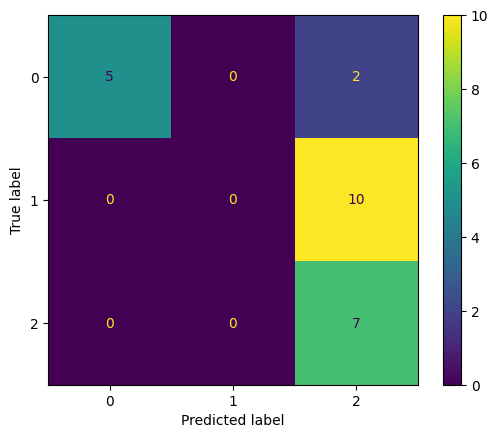

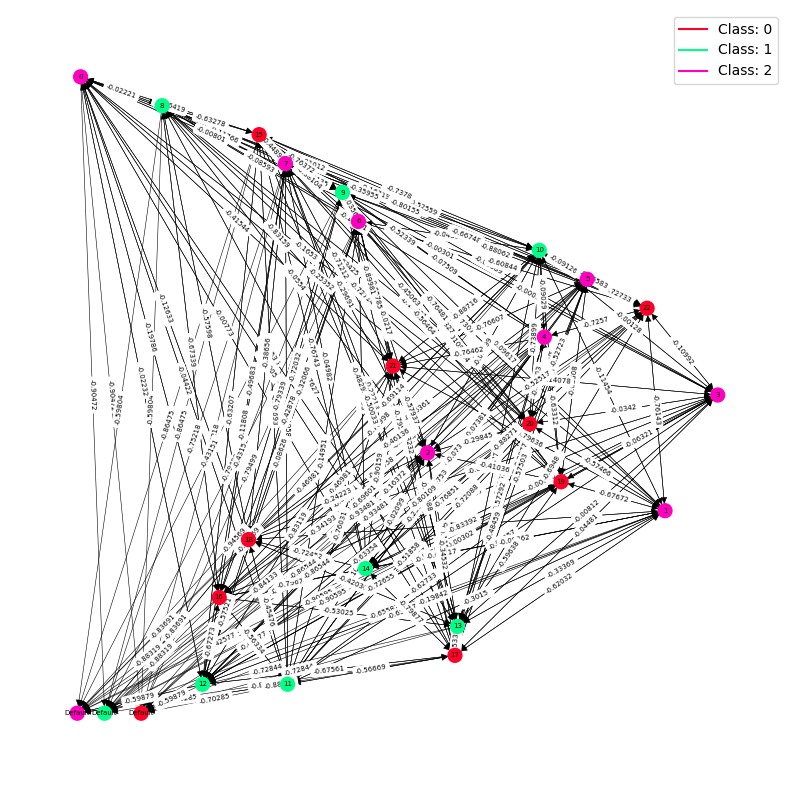

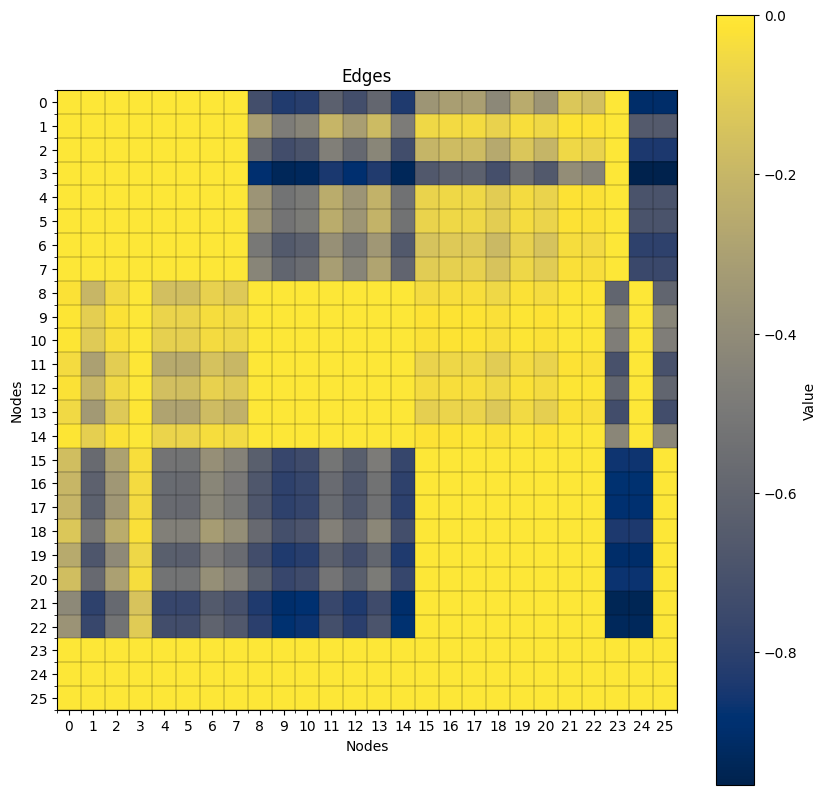

ValueError: Image size of 1647x134558 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 2000x500 with 1 Axes>

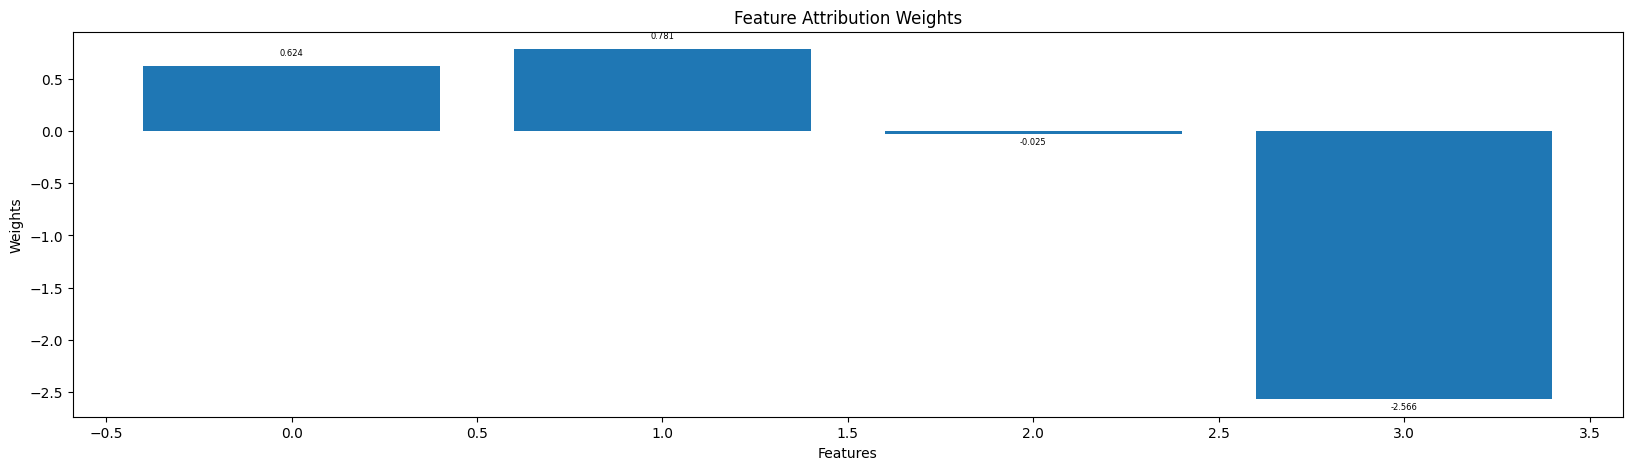

In [21]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=False, print_graph=True  )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [22]:
assert(False)

AssertionError: 

### Hyperparameter Tuning

In [ ]:
search_space = {
    "train": static_train_model,
    # "use_blockers": tune.choice([True, False]),
    "use_blockers": True,
    "no_iters": tune.choice([15, 20, 25]),
    "epochs": tune.choice([250, 750, 1500, 3000]),
    "lr": tune.loguniform(1e-3, 1e-1),
    "momentum": tune.uniform(0.5, 0.99),
    "sharpness": tune.loguniform(1e-1, 1e1),
    "use_symmetric_attacks": tune.choice([True, False]),
    "semantics": tune.sample_from(lambda config: rs.ReluSemantics(max_iters=config["no_iters"], epsilon=0)),
    "activation": tune.choice([torch.sigmoid, torch.relu]),
    "partial_order": tune.sample_from(lambda config: smpo.SMPartialOrder(no_features, sharpness=config["sharpness"], activation=config["activation"])),
    "irrelevance": tune.sample_from(lambda config: ri.RegularIrrelevance(config["partial_order"])),
    "base_score": fwbs.FeatureWeightedBaseScore(no_features),
}


In [ ]:
best_results = tune_model(search_space, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, 
                          X_train, y_train, X_val, y_val, 
                          metric="f1", num_samples=1000, disable_tqdm=True)


2024-11-20 11:59:51,327	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', '8cecdf80')}
2024-11-20 11:59:57,483	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', '8cecdf80')}
2024-11-20 12:00:02,847	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', '8cecdf80')}
2024-11-20 12:00:17,966	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', 'bcab2133')}
2024-11-20 12:00:25,185	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', '8cecdf80')}
2024-11-20 12:00:35,753	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', 'bcab2133')}
2024

BEST PARAMETERS FOR MODEL ARE:
{'train': <function static_train_model at 0x7308a59d72e0>, 'use_blockers': True, 'no_iters': 15, 'epochs': 3000, 'lr': 0.0028868905269400576, 'momentum': 0.8235160343512691, 'sharpness': 0.6175575654691215, 'use_symmetric_attacks': True, 'semantics': <deeparguing.semantics.relu_semantics.ReluSemantics object at 0x7308fce38530>, 'activation': <built-in method relu of type object at 0x7309c99897e0>, 'partial_order': SMPartialOrder(), 'irrelevance': RegularIrrelevance(
  (compute_partial_order): SMPartialOrder()
), 'base_score': FeatureWeightedBaseScore()}
Best score found was:  0.7094017094017094


In [ ]:
print(best_results)


{'train': <function static_train_model at 0x7308a59d72e0>, 'use_blockers': True, 'no_iters': 15, 'epochs': 3000, 'lr': 0.0028868905269400576, 'momentum': 0.8235160343512691, 'sharpness': 0.6175575654691215, 'use_symmetric_attacks': True, 'semantics': <deeparguing.semantics.relu_semantics.ReluSemantics object at 0x7308fce38530>, 'activation': <built-in method relu of type object at 0x7309c99897e0>, 'partial_order': SMPartialOrder(), 'irrelevance': RegularIrrelevance(
  (compute_partial_order): SMPartialOrder()
), 'base_score': FeatureWeightedBaseScore()}


Epoch 3000, Loss: 0.0114: 100%|██████████| 3000/3000 [00:18<00:00, 161.81it/s]


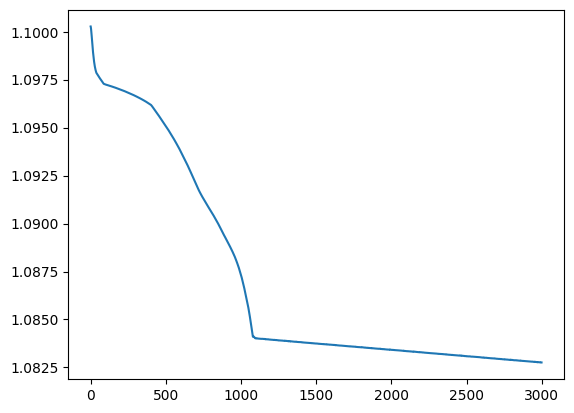

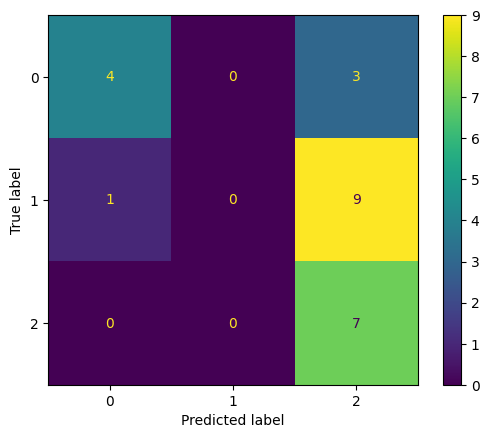

{'f1': np.float64(0.40170940170940167),
 'accuracy': 0.4583333333333333,
 'precision': np.float64(0.38947368421052636),
 'recall': np.float64(0.5238095238095238)}

In [ ]:
# best_results = {'no_iters': 20, 'epochs': 3000, 'lr': 0.027724410326258685, 'sharpness': 0.6052368105626966, "momentum": 0.9, 'seed': 36, 'symmetric_attacks': False}



partial_order = smpo.SMPartialOrder(no_features, sharpness=best_results["sharpness"], activation=best_results["activation"])
irrelevance = ri.RegularIrrelevance(partial_order)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

params = {
    "train": static_train_model,
    "use_blockers": best_results["use_blockers"],
    "epochs": best_results["epochs"],
    "lr": best_results["lr"],
    "momentum": best_results["momentum"],
    "use_symmetric_attacks": best_results["use_symmetric_attacks"],
    "semantics": semantics,
    "partial_order": partial_order,
    "irrelevance": irrelevance,
    "base_score": base_score,
}



objective(params, 
          X_casebase=X_centroids, 
          y_casebase=y_centroids, 
          X_default=X_DEFAULTS, 
          y_default=Y_DEFAULTS, 
          X_train_new_cases=X_train, 
          y_train_new_cases=y_train, 
          X_eval_new_cases=X_val, 
          y_eval_new_cases=y_val, 
          show_confusion=True, 
          plot_loss_curve = True)


### Test Set

In [ ]:
reload_imports()
objective(params, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_train_full, y_train_full, X_test, y_test, show_confusion=True, plot_loss_curve = True)

## Baselines

In [ ]:
from sklearn import neighbors
from sklearn import tree
from sklearn.linear_model import LogisticRegression

y_centroids_label = torch.argmax(y_centroids, dim=1)

logistic_regression = LogisticRegression()
logistic_regression.fit(X_centroids, y_centroids_label)
logistic_predictions = logistic_regression.predict(X_test)
print('Accuracy with Logistic Regression is %.2f' % (accuracy_score(np.argmax(y_test, axis=1), logistic_predictions) * 100))
print('Precision with Logistic Regression is %.2f' % (precision_score(np.argmax(y_test, axis=1), logistic_predictions, average="macro") * 100))
print('Recall with Logistic Regression is %.2f' % (recall_score(np.argmax(y_test, axis=1), logistic_predictions, average="macro") * 100))
print('F1 with Logistic Regression is %.2f' % (f1_score(np.argmax(y_test, axis=1), logistic_predictions, average="macro") * 100))

# %% KNeighborsClassifier
k_classifier = neighbors.KNeighborsClassifier()
k_classifier.fit(X_centroids, y_centroids_label)
k_neighbors_predictions = k_classifier.predict(X_test)
print('Accuracy with KNeighborsClassifier is %.2f' % (accuracy_score(np.argmax(y_test, axis=1), k_neighbors_predictions) * 100))

# %% DecisionTreeClassifier
decision_classifier = tree.DecisionTreeClassifier()
decision_classifier.fit(X_centroids, y_centroids_label)
decision_classifier_predictions = decision_classifier.predict(X_test)
print('Accuracy with DecisionTreeClassifier is %.2f' % (accuracy_score(np.argmax(y_test, axis=1), decision_classifier_predictions) * 100))
